# 08 - Targeted Improvement on Promotions and High Sales

## Objective

Use the insights from NB7 to improve the model on the most critical error segments:

- promotion periods
- high sales observations
- demand spikes

This notebook does not randomly test new models.

The goal is to evaluate whether targeted feature engineering can reduce errors in the scenarios where the validated model struggles the most.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

sys.path.append(str(Path().resolve().parent))

from src.features import (
    add_baseline_features,
    add_advanced_features,
    add_targeted_features,
    encode_family,
)
from src.metrics import evaluate_regression
from src.evaluation import evaluate_feature_set

## Setup

Use the full dataset and the same walk-forward validation strategy used in NB5 full data and NB7.

The only change introduced in this notebook is the feature set.

In [4]:
SEED = 42
DATA_DIR = Path("../data")

N_FOLDS = 4
VAL_SIZE = 28

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


## Load data

In [5]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Base preprocessing

Sort the data and recreate the calendar features used in the previous notebooks.

In [6]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

display(train.head())

,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,weekofyear,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2013,1,2,2,1,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,2013,1,3,3,1,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,2013,1,4,4,1,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,2013,1,5,5,1,1


## Baseline advanced feature set

Rebuild the validated advanced feature pipeline from previous notebooks.

This will be used as the reference model.

In [7]:
advanced_train = add_baseline_features(train)
advanced_train = add_advanced_features(advanced_train)
advanced_train = advanced_train.dropna().copy()

advanced_train, advanced_test, family_mapping = encode_family(advanced_train, test)

advanced_features_v1 = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7",
]

print("Advanced V1 shape:", advanced_train.shape)
print("Date range:", advanced_train["date"].min(), "->", advanced_train["date"].max())
print("Number of V1 features:", len(advanced_features_v1))

Advanced V1 shape: (2975940, 19)
Date range: 2013-01-15 00:00:00 -> 2017-08-15 00:00:00
Number of V1 features: 16


## Build targeted V2 dataset

Create a second feature set that extends the validated advanced pipeline.

In [8]:
targeted_train = add_targeted_features(advanced_train.copy())
targeted_train = targeted_train.dropna().copy()

targeted_features_v2 = advanced_features_v1 + [
    "is_promo",
    "promo_intensity",
    "promo_rolling_mean_7",
    "promo_rolling_sum_14",
    "rolling_max_7",
    "rolling_max_14",
    "rolling_std_14",
    "sales_spike_ratio_7",
]

print("Targeted V2 shape:", targeted_train.shape)
print("Date range:", targeted_train["date"].min(), "->", targeted_train["date"].max())
print("Number of V2 features:", len(targeted_features_v2))

display(targeted_train[targeted_features_v2].head())

Targeted V2 shape: (2950992, 27)
Date range: 2013-01-29 00:00:00 -> 2017-08-15 00:00:00
Number of V2 features: 24


,store_nbr,family,onpromotion,year,month,day,dayofweek,weekofyear,is_weekend,lag_1,...,trend_1_7,promo_last_7,is_promo,promo_intensity,promo_rolling_mean_7,promo_rolling_sum_14,rolling_max_7,rolling_max_14,rolling_std_14,sales_spike_ratio_7
49896,1,0,0,2013,1,29,1,5,0,3.0,...,2.0,0.0,0,0,0.0,0.0,5.0,5.0,1.703261,0.840000
51678,1,0,0,2013,1,30,2,5,0,2.0,...,-1.0,0.0,0,0,0.0,0.0,5.0,5.0,1.672335,0.538462
53460,1,0,0,2013,1,31,3,5,0,6.0,...,6.0,0.0,0,0,0.0,0.0,6.0,6.0,1.910066,1.448276
55242,1,0,0,2013,2,1,4,5,0,0.0,...,-5.0,0.0,0,0,0.0,0.0,6.0,6.0,1.990361,0.000000
57024,1,0,0,2013,2,2,5,5,1,3.0,...,-1.0,0.0,0,0,0.0,0.0,6.0,6.0,1.857565,0.777778


## Rebuild validation folds

Use the same recent walk-forward validation setup.

This makes the comparison between V1 and V2 fair.

In [9]:
unique_dates = np.array(sorted(targeted_train["date"].unique()))

folds = []
last_val_end_idx = len(unique_dates) - 1

for i in range(N_FOLDS):
    offset = (N_FOLDS - 1 - i) * VAL_SIZE

    val_end_idx = last_val_end_idx - offset
    val_start_idx = val_end_idx - VAL_SIZE + 1
    train_end_idx = val_start_idx - 1

    if train_end_idx < 365:
        break

    folds.append({
        "fold": i + 1,
        "train_end": unique_dates[train_end_idx],
        "val_start": unique_dates[val_start_idx],
        "val_end": unique_dates[val_end_idx],
    })

folds_df = pd.DataFrame(folds)
display(folds_df)

,fold,train_end,val_start,val_end
0,1,2017-04-25,2017-04-26,2017-05-23
1,2,2017-05-23,2017-05-24,2017-06-20
2,3,2017-06-20,2017-06-21,2017-07-18
3,4,2017-07-18,2017-07-19,2017-08-15


## Evaluate Advanced V1

Evaluate the validated advanced feature set as reference.

In [10]:
metrics_v1, errors_v1 = evaluate_feature_set(
    df=targeted_train,
    features=advanced_features_v1,
    model_name="advanced_v1",
    folds=folds,
)

display(metrics_v1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2185
[LightGBM] [Info] Number of data points in the train set: 2751408, number of used features: 16
[LightGBM] [Info] Start training from score 351.740428
advanced_v1 | Fold 1 | RMSLE=0.602253 | MAE=78.524 | RMSE=298.884 | R2=0.952200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2186
[LightGBM] [Info] Number of data points in the train set: 2801304, number of used features: 16
[LightGBM] [Info] Start training from score 354.222265
advanced_v1 | Fold 2 | RMSLE=0.612706 | MAE=71.487 | RMSE=265.591 | R2=0.963417
[LightGBM] [Info] Au

,rmsle,mae,rmse,r2,fold,model
0,0.602253,78.524363,298.884310,0.952200,1,advanced_v1
1,0.612706,71.486646,265.591235,0.963417,2,advanced_v1
2,0.586664,58.278865,211.982492,0.974400,3,advanced_v1
3,0.616692,65.387419,218.216799,0.970502,4,advanced_v1


## Evaluate Targeted V2

Evaluate the new targeted feature set.

In [11]:
metrics_v2, errors_v2 = evaluate_feature_set(
    df=targeted_train,
    features=targeted_features_v2,
    model_name="targeted_v2",
    folds=folds,
)

display(metrics_v2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3915
[LightGBM] [Info] Number of data points in the train set: 2751408, number of used features: 24
[LightGBM] [Info] Start training from score 351.740428
targeted_v2 | Fold 1 | RMSLE=0.614633 | MAE=77.839 | RMSE=297.337 | R2=0.952694
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3917
[LightGBM] [Info] Number of data points in the train set: 2801304, number of used features: 24
[LightGBM] [Info] Start training from score 354.222265
targeted_v2 | Fold 2 | RMSLE=0.617462 | MAE=71.759 | RMSE=267.026 | R2=0.963021
[LightGBM] [Info] Au

,rmsle,mae,rmse,r2,fold,model
0,0.614633,77.838671,297.337054,0.952694,1,targeted_v2
1,0.617462,71.759436,267.025947,0.963021,2,targeted_v2
2,0.592183,57.374319,208.763054,0.975172,3,targeted_v2
3,0.613134,65.242678,217.794543,0.970616,4,targeted_v2


## Global comparison

Compare V1 and V2 across validation folds.

In [12]:
metrics_all = pd.concat([metrics_v1, metrics_v2], ignore_index=True)

comparison_summary = (
    metrics_all
    .groupby("model")
    .agg(
        rmsle_mean=("rmsle", "mean"),
        rmsle_std=("rmsle", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        r2_mean=("r2", "mean"),
    )
    .reset_index()
)

display(comparison_summary)

,model,rmsle_mean,rmsle_std,mae_mean,mae_std,rmse_mean,r2_mean
0,advanced_v1,0.604579,0.013406,68.419323,8.632142,248.668709,0.965130
1,targeted_v2,0.609353,0.011586,68.053776,8.783112,247.730149,0.965375


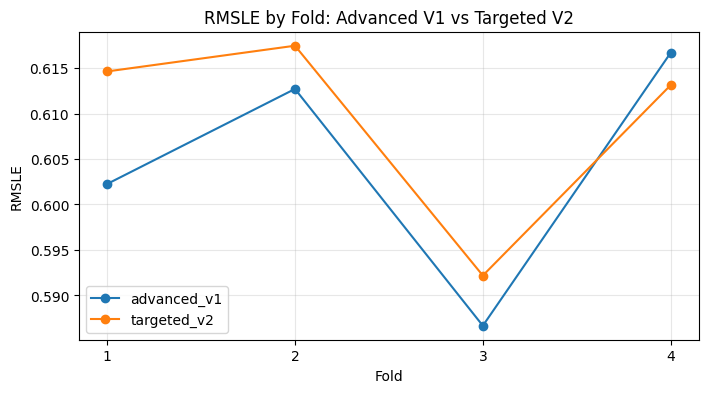

In [13]:
plt.figure(figsize=(8, 4))

for model_name, group in metrics_all.groupby("model"):
    plt.plot(group["fold"], group["rmsle"], marker="o", label=model_name)

plt.title("RMSLE by Fold: Advanced V1 vs Targeted V2")
plt.xlabel("Fold")
plt.ylabel("RMSLE")
plt.xticks(sorted(metrics_all["fold"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

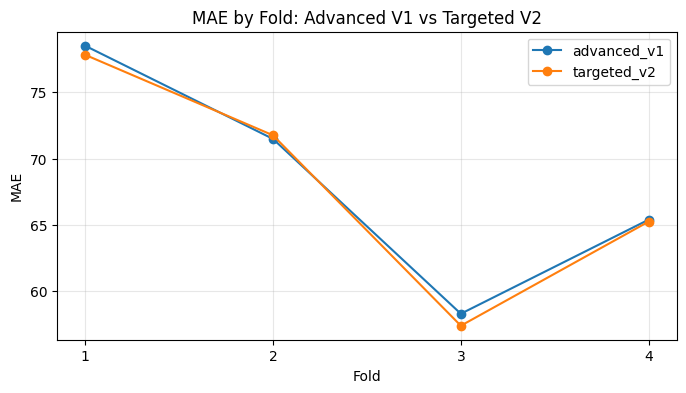

In [14]:
plt.figure(figsize=(8, 4))

for model_name, group in metrics_all.groupby("model"):
    plt.plot(group["fold"], group["mae"], marker="o", label=model_name)

plt.title("MAE by Fold: Advanced V1 vs Targeted V2")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.xticks(sorted(metrics_all["fold"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Segment-level comparison

Compare whether the targeted features improve the most critical segments:

- promotion periods
- high sales observations
- weekend periods

In [15]:
def add_analysis_columns(errors_df: pd.DataFrame) -> pd.DataFrame:
    df = errors_df.copy()

    df["promo_flag"] = (df["onpromotion"] > 0).astype(int)

    df["sales_bin"] = pd.qcut(
        df["sales"].rank(method="first"),
        q=4,
        labels=["Low", "Medium-low", "Medium-high", "High"]
    )

    return df


errors_v1_analysis = add_analysis_columns(errors_v1)
errors_v2_analysis = add_analysis_columns(errors_v2)

errors_all = pd.concat([errors_v1_analysis, errors_v2_analysis], ignore_index=True)

print("Errors all shape:", errors_all.shape)
display(errors_all.head())

Errors all shape: (399168, 35)


,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,...,rolling_std_14,sales_spike_ratio_7,model,fold,y_pred,error,abs_error,squared_error,promo_flag,sales_bin
0,2801304,2017-04-26,1,0,2.0,0,2017,4,26,2,...,2.307418,0.636364,advanced_v1,1,3.102914,-1.102914,1.102914,1.216419,0,Low
1,2803086,2017-04-27,1,0,8.0,0,2017,4,27,3,...,2.334641,0.451613,advanced_v1,1,2.548085,5.451915,5.451915,29.723372,0,Medium-low
2,2804868,2017-04-28,1,0,3.0,0,2017,4,28,4,...,2.154729,1.513514,advanced_v1,1,4.385893,-1.385893,1.385893,1.920698,0,Low
3,2806650,2017-04-29,1,0,2.0,0,2017,4,29,5,...,2.060886,0.600000,advanced_v1,1,7.453281,-5.453281,5.453281,29.738271,0,Low
4,2808432,2017-04-30,1,0,3.0,0,2017,4,30,6,...,2.091322,0.437500,advanced_v1,1,0.000000,3.000000,3.000000,9.000000,0,Low


In [16]:
promo_comparison = (
    errors_all
    .groupby(["model", "promo_flag"])
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
    .reset_index()
)

promo_comparison["promo_segment"] = promo_comparison["promo_flag"].map({
    0: "No promotion",
    1: "Promotion"
})

display(promo_comparison)

,model,promo_flag,mean_abs_error,median_abs_error,mean_sales,count,promo_segment
0,advanced_v1,0,11.542223,2.754507,60.816486,109126,No promotion
1,advanced_v1,1,137.034265,35.799493,991.797796,90458,Promotion
2,targeted_v2,0,11.443637,2.875046,60.816486,109126,No promotion
3,targeted_v2,1,136.346664,35.333811,991.797796,90458,Promotion


In [17]:
sales_bin_comparison = (
    errors_all
    .groupby(["model", "sales_bin"])
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
    .reset_index()
)

display(sales_bin_comparison)

,model,sales_bin,mean_abs_error,median_abs_error,mean_sales,count
0,advanced_v1,Low,2.439785,1.772564,0.863003,49896
1,advanced_v1,Medium-low,5.841034,3.734101,12.554752,49896
2,advanced_v1,Medium-high,27.646191,18.632876,120.892900,49896
3,advanced_v1,High,237.750282,103.417185,1796.760069,49896
4,targeted_v2,Low,2.477861,1.758310,0.863003,49896
5,targeted_v2,Medium-low,6.024119,3.939812,12.554752,49896
6,targeted_v2,Medium-high,27.323496,18.518770,120.892900,49896
7,targeted_v2,High,236.389627,102.985717,1796.760069,49896


In [18]:
weekend_comparison = (
    errors_all
    .groupby(["model", "is_weekend"])
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_sales=("sales", "mean"),
        count=("abs_error", "size")
    )
    .reset_index()
)

weekend_comparison["segment"] = weekend_comparison["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

display(weekend_comparison)

,model,is_weekend,mean_abs_error,median_abs_error,mean_sales,count,segment
0,advanced_v1,0,61.010696,7.092671,437.757029,142560,Weekday
1,advanced_v1,1,86.940890,8.920461,595.294311,57024,Weekend
2,targeted_v2,0,60.615271,7.066046,437.757029,142560,Weekday
3,targeted_v2,1,86.650038,9.368109,595.294311,57024,Weekend


## Improvement analysis

Compute relative improvement for the most important segments.

In [19]:
def compute_segment_improvement(segment_df, segment_col, metric_col="mean_abs_error"):
    pivot = segment_df.pivot(
        index=segment_col,
        columns="model",
        values=metric_col
    ).reset_index()

    pivot["absolute_delta"] = pivot["targeted_v2"] - pivot["advanced_v1"]
    pivot["relative_delta_pct"] = (
        (pivot["targeted_v2"] - pivot["advanced_v1"]) /
        pivot["advanced_v1"]
    ) * 100

    return pivot

In [20]:
promo_improvement = compute_segment_improvement(
    promo_comparison,
    segment_col="promo_segment"
)

sales_bin_improvement = compute_segment_improvement(
    sales_bin_comparison,
    segment_col="sales_bin"
)

weekend_improvement = compute_segment_improvement(
    weekend_comparison,
    segment_col="segment"
)

print("Promotion improvement")
display(promo_improvement)

print("Sales bin improvement")
display(sales_bin_improvement)

print("Weekend improvement")
display(weekend_improvement)

Promotion improvement


model,promo_segment,advanced_v1,targeted_v2,absolute_delta,relative_delta_pct
0,No promotion,11.542223,11.443637,-0.098586,-0.854136
1,Promotion,137.034265,136.346664,-0.687601,-0.501773


Sales bin improvement


model,sales_bin,advanced_v1,targeted_v2,absolute_delta,relative_delta_pct
0,Low,2.439785,2.477861,0.038076,1.560625
1,Medium-low,5.841034,6.024119,0.183086,3.134472
2,Medium-high,27.646191,27.323496,-0.322695,-1.167231
3,High,237.750282,236.389627,-1.360655,-0.572304


Weekend improvement


model,segment,advanced_v1,targeted_v2,absolute_delta,relative_delta_pct
0,Weekday,61.010696,60.615271,-0.395425,-0.648125
1,Weekend,86.940890,86.650038,-0.290852,-0.334540


## Interpretation

The targeted features are useful only if they improve the critical segments identified in NB7.

Important:

- a small global improvement is useful
- a segment-level improvement on promotions or high sales is even more valuable
- if global metrics do not improve, the experiment may still provide useful diagnostic information

In [21]:
def get_value(df, col, value, model):
    return df[(df[col] == value) & (df["model"] == model)]["mean_abs_error"].values[0]


promo_v1 = get_value(promo_comparison, "promo_segment", "Promotion", "advanced_v1")
promo_v2 = get_value(promo_comparison, "promo_segment", "Promotion", "targeted_v2")

high_v1 = get_value(sales_bin_comparison, "sales_bin", "High", "advanced_v1")
high_v2 = get_value(sales_bin_comparison, "sales_bin", "High", "targeted_v2")

weekend_v1 = get_value(weekend_comparison, "segment", "Weekend", "advanced_v1")
weekend_v2 = get_value(weekend_comparison, "segment", "Weekend", "targeted_v2")

print("Critical segment comparison")
print("---------------------------")
print(f"Promotion MAE | V1: {promo_v1:.2f} | V2: {promo_v2:.2f} | Delta: {promo_v2 - promo_v1:.2f}")
print(f"High sales MAE | V1: {high_v1:.2f} | V2: {high_v2:.2f} | Delta: {high_v2 - high_v1:.2f}")
print(f"Weekend MAE | V1: {weekend_v1:.2f} | V2: {weekend_v2:.2f} | Delta: {weekend_v2 - weekend_v1:.2f}")

Critical segment comparison
---------------------------
Promotion MAE | V1: 137.03 | V2: 136.35 | Delta: -0.69
High sales MAE | V1: 237.75 | V2: 236.39 | Delta: -1.36
Weekend MAE | V1: 86.94 | V2: 86.65 | Delta: -0.29


## Conclusion

This notebook tested targeted feature engineering based on NB7 error analysis.

The experiment focuses on:

- promotions
- high sales observations
- weekend volatility

The goal is not to randomly improve the model, but to evaluate whether specific features can reduce errors in the most business-critical scenarios.

Possible outcomes:

### If V2 improves global and segment metrics

The targeted features should be considered for the next model candidate.

### If V2 improves only critical segments

The trade-off should be evaluated because business-critical improvements may be more important than small global metric changes.

### If V2 does not improve

The analysis is still useful because it shows that the current issue may require:

- external features
- holiday/event data
- stronger promotion modeling
- segment-specific models

This is a controlled ML experiment driven by model diagnosis, not by random feature exploration.

## Final Interpretation

Targeted V2 introduces promotion and high-sales features based on the error patterns identified in NB7.

The experiment shows only marginal improvements on the most critical segments:

- Promotion MAE: 137.03 → 136.35
- High sales MAE: 237.75 → 236.39
- Weekend MAE: 86.94 → 86.65

However, the global RMSLE slightly worsens:

- Advanced V1 RMSLE mean ≈ 0.6046
- Targeted V2 RMSLE mean ≈ 0.6094

Therefore, Targeted V2 should not replace the current final model.

The result suggests that the main forecasting errors are not solved by simple rolling promotion and spike features. More informative external signals, such as holidays, events, stronger promotion modeling, or segment-specific models, may be required.

## Decision

Targeted V2 is useful as a diagnostic experiment, but it should not replace Advanced V1 / the current final model.